In [1]:
from IPython.display import HTML
HTML("""
<style>
body { font-size: 10px; }
h1, h2, h3 { color: #ff4da6; }
</style>
""")

<h1 align="center" style="font-size:22pt; font-family:'Georgia',serif; color:#FFFFFF; letter-spacing:1px;">
🫀 Low-Cost AI-Enabled Murmur Analysis Tool
</h1>

<h3 align="center" style="font-size:14pt; font-family:'Georgia',serif; color:#F2F2F2;">
Early Detection of Rheumatic Heart Disease Using PCG Spectrograms
</h3>

<p align="center" style="font-size:12pt; font-family:'Georgia',serif; color:#E8DAEF;">
✨ CNN + BiLSTM • Explainable AI • Research-Grade Pipeline ✨
</p>




In [2]:
import torch

# Check if CUDA is available
print("CUDA Available:", torch.cuda.is_available())

# Get the name of the GPU
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [3]:
import os

print("Inside 2022 folder:")
print(os.listdir(os.path.join(os.getcwd(), "2022")))

Inside 2022 folder:
['training', 'training_data.csv']


<div style="font-family: Georgia, serif; font-size: 11pt;">

# 🧾 Dataset Collection & Organization

This step prepares a **unified heart sound dataset** from:

- 📁 PhysioNet 2016  
- 📁 PhysioNet 2022  

---

## ⚙️ What it does

- ✅ Loads audio paths and labels  
- ✅ Converts labels → **Normal / Murmur**  
- ✅ Extracts **patient_id** (for leakage-free training)  
- ❌ Excludes validation data (2016)  
- 🔗 Merges both datasets  
- 🧹 Removes duplicates  

---

## 📊 Output

Final dataset saved as: unified_murmur_dataset

</div>

In [4]:
# ==========================================
# DATASET COLLECTION & ORGANIZATION (FINAL)
# ==========================================

import os
import glob
import pandas as pd

# ------------------------------------------
# STEP 1: BASE PATH
# ------------------------------------------
BASE_DIR = os.getcwd()

PHYSIONET_2016_DIR = os.path.join(BASE_DIR, "2016")
PHYSIONET_2022_DIR = os.path.join(BASE_DIR, "2022")

print(f"✅ Working Directory: {BASE_DIR}")

# ------------------------------------------
# STEP 2: PARSE PHYSIONET 2016
# ------------------------------------------
def process_physionet_2016(base_path):
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"❌ 2016 dataset not found: {base_path}")

    data_list = []

    # Only include training folders
    folders = [
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f)) and "training" in f.lower()
    ]

    print(f"📁 2016 folders used: {folders}")

    for folder in folders:
        folder_path = os.path.join(base_path, folder)

        ref_csv = glob.glob(os.path.join(folder_path, "*.csv"))
        if not ref_csv:
            continue

        df_ref = pd.read_csv(ref_csv[0], names=['filename', 'label'])

        for _, row in df_ref.iterrows():
            wav_name = str(row['filename'])

            if not wav_name.endswith('.wav'):
                wav_name += '.wav'

            audio_path = os.path.join(folder_path, wav_name)

            if os.path.exists(audio_path):
                label = 'Normal' if row['label'] == -1 else 'Murmur'

                data_list.append({
                    'audio_path': audio_path,
                    'dataset_source': f'PhysioNet_2016_{folder}',
                    'label': label,
                    'patient_id': wav_name.split('_')[0]  # fallback grouping
                })

    return pd.DataFrame(data_list)

# ------------------------------------------
# STEP 3: PARSE PHYSIONET 2022
# ------------------------------------------
def process_physionet_2022(base_path):
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"❌ 2022 dataset not found: {base_path}")

    data_list = []

    csv_path = os.path.join(base_path, "training_data.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ training_data.csv not found at {csv_path}")

    df_labels = pd.read_csv(csv_path)
    df_labels.columns = df_labels.columns.str.strip()

    pid_col = 'Patient_ID'
    murmur_col = 'Murmurs'

    for _, row in df_labels.iterrows():
        patient_id = str(row[pid_col])
        murmur_status = str(row[murmur_col]).strip()

        if murmur_status == 'Unknown':
            continue

        label = 'Murmur' if murmur_status == 'Present' else 'Normal'

        wav_paths = glob.glob(
            os.path.join(base_path, "training", f"{patient_id}_*.wav")
        )

        if not wav_paths:
            continue

        for wav_path in wav_paths:
            data_list.append({
                'audio_path': wav_path,
                'dataset_source': 'PhysioNet_2022',
                'label': label,
                'patient_id': patient_id
            })

    return pd.DataFrame(data_list)

# ------------------------------------------
# STEP 4: RUN EXTRACTION
# ------------------------------------------
df_2016 = process_physionet_2016(PHYSIONET_2016_DIR)
print(f"✅ Extracted {len(df_2016)} records from PhysioNet 2016")

df_2022 = process_physionet_2022(PHYSIONET_2022_DIR)
print(f"✅ Extracted {len(df_2022)} records from PhysioNet 2022")

# ------------------------------------------
# STEP 5: MERGE DATASETS
# ------------------------------------------
unified_df = pd.concat([df_2016, df_2022], ignore_index=True)

# Remove duplicate audio paths
unified_df = unified_df.drop_duplicates(subset=['audio_path'])

# ------------------------------------------
# STEP 6: DATASET SUMMARY
# ------------------------------------------
print("\n📊 Final Dataset Distribution:")
print(unified_df['label'].value_counts())

print("\n📊 Source Distribution:")
print(unified_df['dataset_source'].value_counts())

# ------------------------------------------
# STEP 7: SAVE CSV
# ------------------------------------------
output_csv = os.path.join(BASE_DIR, "unified_murmur_dataset.csv")
unified_df.to_csv(output_csv, index=False)

print(f"\n✅ Dataset saved at: {output_csv}")

✅ Working Directory: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)
📁 2016 folders used: ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
✅ Extracted 3240 records from PhysioNet 2016
✅ Extracted 1604 records from PhysioNet 2022

📊 Final Dataset Distribution:
label
Normal    4179
Murmur     665
Name: count, dtype: int64

📊 Source Distribution:
dataset_source
PhysioNet_2016_training-e    2141
PhysioNet_2022               1604
PhysioNet_2016_training-b     490
PhysioNet_2016_training-a     409
PhysioNet_2016_training-f     114
PhysioNet_2016_training-d      55
PhysioNet_2016_training-c      31
Name: count, dtype: int64

✅ Dataset saved at: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\unified_murmur_dataset.csv


<div style="font-family: Georgia, serif; font-size: 11pt;">

## 📊 Label Distribution

The bar chart illustrates the distribution of Normal and Murmur samples in the dataset.

---

### 🔍 Interpretation

- The dataset is **highly imbalanced**:
  - 🟢 **Normal samples** are significantly higher  
  - 🔴 **Murmur samples** are much fewer  

- This reflects real-world medical scenarios where abnormal cases are less frequent.

---

### ⚠️ Implication

- The model may become **biased toward predicting Normal**
- To address this, we incorporate:
  - ✅ Class weighting during training  
  - ✅ Recall-focused evaluation (important for murmur detection)

---

✨ This analysis highlights the importance of handling class imbalance in the model.

</div>

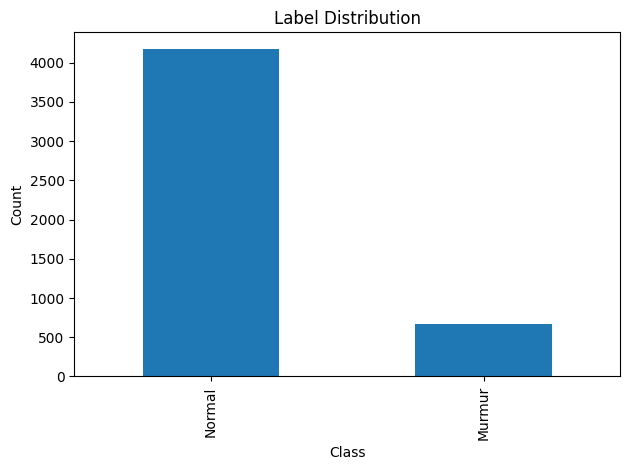

In [5]:
import matplotlib.pyplot as plt

plt.figure()
unified_df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🎧 Audio Preprocessing

Standardizes and cleans PCG signals for model-ready input.

---

### ⚙️ Key Steps
- Resample to **2000 Hz**
- Apply **bandpass filter (20–400 Hz)**
- Normalize amplitude
- Remove very short/corrupt files
- Save cleaned audio

---

### 📦 Output
- 📁 `processed_audio/`
- 📄 `preprocessed_dataset.csv`  
  (includes `clean_audio_path`, label, source, patient_id)

---

### 🔍 Summary
- ✔ Clean, standardized signals  
- ❌ Invalid files removed  
- 🎯 Ready for feature extraction  

</div>

In [5]:
# ==========================================
# AUDIO PREPROCESSING (FINAL OPTIMIZED)
# ==========================================

import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from scipy.signal import butter, filtfilt
from tqdm import tqdm

# ------------------------------------------
# CONFIG
# ------------------------------------------
BASE_DIR = "."

INPUT_CSV = os.path.join(BASE_DIR, "unified_murmur_dataset.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "processed_audio")
OUTPUT_CSV = os.path.join(BASE_DIR, "preprocessed_dataset.csv")

TARGET_SR = 2000
LOWCUT = 20.0
HIGHCUT = 400.0
FILTER_ORDER = 4

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------
# FILTER FUNCTION
# ------------------------------------------
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 0.001)
    high = min(highcut / nyq, 0.99)

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ------------------------------------------
# PREPROCESS FUNCTION
# ------------------------------------------
def preprocess_audio(file_path, save_path):
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None, mono=True)

        # Handle short audio (pad instead of skipping)
        if len(y) < sr:
            y = np.pad(y, (0, sr - len(y)))

        # Resample
        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)

        # Bandpass filter
        y = butter_bandpass_filter(y, LOWCUT, HIGHCUT, TARGET_SR, FILTER_ORDER)

        # Normalize
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val

        # Save as WAV
        sf.write(save_path, y, TARGET_SR)

        return True

    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return False

# ------------------------------------------
# MAIN EXECUTION
# ------------------------------------------
df = pd.read_csv(INPUT_CSV)

processed_paths = []
valid_indices = []
failed_files = []

print(f"🚀 Processing {len(df)} files...")

for index in tqdm(range(len(df))):
    row = df.iloc[index]

    orig_path = row['audio_path']
    filename = os.path.basename(orig_path)

    # Ensure proper .wav output name
    name = os.path.splitext(filename)[0]
    save_filename = f"clean_{index}_{name}.wav"
    save_path = os.path.join(OUTPUT_DIR, save_filename)

    success = preprocess_audio(orig_path, save_path)

    if success:
        processed_paths.append(save_path)
        valid_indices.append(index)
    else:
        failed_files.append(orig_path)

# ------------------------------------------
# BUILD CLEAN DATASET
# ------------------------------------------
df_clean = df.loc[valid_indices].copy()
df_clean['clean_audio_path'] = processed_paths

df_clean.to_csv(OUTPUT_CSV, index=False)

# ------------------------------------------
# SUMMARY
# ------------------------------------------
print("\n✅ Preprocessing complete")
print(f"✔ Processed files: {len(df_clean)}")
print(f"❌ Failed files: {len(failed_files)}")
print(f"⚠️ Failure rate: {len(failed_files)/len(df)*100:.2f}%")
print(f"📁 Output folder: {OUTPUT_DIR}")
print(f"📄 CSV saved at: {OUTPUT_CSV}")

🚀 Processing 4844 files...


  0%|          | 0/4844 [00:00<?, ?it/s]

100%|██████████| 4844/4844 [00:20<00:00, 234.55it/s]


✅ Preprocessing complete
✔ Processed files: 4844
❌ Failed files: 0
⚠️ Failure rate: 0.00%
📁 Output folder: .\processed_audio
📄 CSV saved at: .\preprocessed_dataset.csv


<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🎧 Waveform Comparison

- Original signal contains noise and varying amplitude  
- Processed signal is cleaner and normalized  
- Heart sound peaks are more clearly visible  

---

✨ Confirms improved signal quality for model input.

</div>

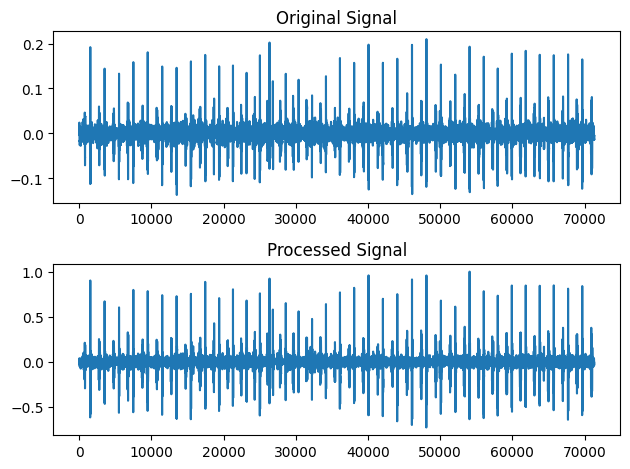

In [7]:
import matplotlib.pyplot as plt
import librosa

orig = unified_df.iloc[0]['audio_path']
clean = df_clean.iloc[0]['clean_audio_path']

y1, sr1 = librosa.load(orig, sr=None)
y2, sr2 = librosa.load(clean, sr=None)

plt.figure()

plt.subplot(2,1,1)
plt.plot(y1)
plt.title("Original Signal")

plt.subplot(2,1,2)
plt.plot(y2)
plt.title("Processed Signal")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 📊 Frequency Spectrum (Before vs After Filtering)

The plot compares the frequency content of the signal before and after applying the bandpass filter.

---

### 🔍 Interpretation

- Before filtering: energy is spread across a wide frequency range, including noise  
- After filtering: frequencies above ~400 Hz are removed  
- Signal energy is concentrated in the **0–200 Hz range**, relevant to heart sounds  

---

✨ Confirms effective noise removal and retention of important cardiac frequencies.

</div>

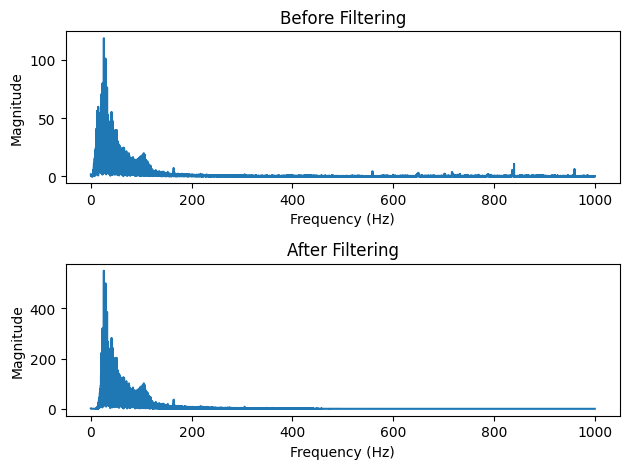

In [8]:
import numpy as np

def plot_fft(signal, sr, title):
    fft = np.abs(np.fft.rfft(signal))
    freq = np.fft.rfftfreq(len(signal), 1/sr)

    plt.plot(freq, fft)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

plt.figure()

plt.subplot(2,1,1)
plot_fft(y1, sr1, "Before Filtering")

plt.subplot(2,1,2)
plot_fft(y2, sr2, "After Filtering")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🧩 Segmentation & Feature Extraction

This step converts cleaned audio into fixed-size spectrogram features for model training.

---

### ⚙️ What it does

- ✂️ Splits audio into **3-second segments**
- 🎼 Converts each segment into **Mel Spectrograms (128 bands)**
- 📏 Ensures **fixed-size input (padding/trimming)**
- 💾 Saves features as `.npy` files
- 🔗 Maintains `patient_id` for leakage-free training  

---

### 📦 Output

- 📁 `spectrograms/` (feature files)  
- 📄 `final_training_dataset.csv`  
  (includes `spectrogram_path`, label, patient_id, source)

---

### 🔍 Summary

- ✔ Uniform input shape for model  
- ✔ Temporal segmentation improves learning  
- ✔ Converts audio → image-like representation  

---

✨ Enables deep learning models to capture heart sound patterns effectively.

</div>

In [9]:
# ==========================================
# SEGMENTATION & FEATURE EXTRACTION (FINAL)
# ==========================================

import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

BASE_DIR = "."
INPUT_CSV = os.path.join(BASE_DIR, "preprocessed_dataset.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "spectrograms")
OUTPUT_CSV = os.path.join(BASE_DIR, "final_training_dataset.csv")

TARGET_SR = 2000
CHUNK_LENGTH_SEC = 3.0
CHUNK_SAMPLES = int(TARGET_SR * CHUNK_LENGTH_SEC)

N_MELS = 128
HOP_LENGTH = 64
N_FFT = 512

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------
# MEL SPECTROGRAM
# ------------------------------------------
def extract_mel_spectrogram(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

# ------------------------------------------
# FIXED SIZE FUNCTION
# ------------------------------------------
def pad_or_trim(spec, target_width=94):
    if spec.shape[1] < target_width:
        pad_width = target_width - spec.shape[1]
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='constant')
    else:
        spec = spec[:, :target_width]
    return spec

# ------------------------------------------
# MAIN
# ------------------------------------------
df = pd.read_csv(INPUT_CSV)

segment_data = []

print("Starting feature extraction...")

for index in tqdm(range(len(df))):
    row = df.iloc[index]

    audio_path = row['clean_audio_path']
    label = row['label']
    source = row['dataset_source']
    patient_id = row['patient_id']   # 🔥 critical

    try:
        y, sr = librosa.load(audio_path, sr=None)

        total_samples = len(y)
        num_chunks = total_samples // CHUNK_SAMPLES

        if num_chunks == 0:
            y = np.pad(y, (0, CHUNK_SAMPLES - total_samples))
            spec = extract_mel_spectrogram(y, sr)
            spec = pad_or_trim(spec)

            save_path = os.path.join(OUTPUT_DIR, f"spec_{index}_0.npy")
            np.save(save_path, spec)

            segment_data.append({
                'spectrogram_path': save_path,
                'label': label,
                'patient_id': patient_id,
                'source': source
            })

        else:
            for i in range(num_chunks):
                start = i * CHUNK_SAMPLES
                end = start + CHUNK_SAMPLES

                chunk = y[start:end]

                spec = extract_mel_spectrogram(chunk, sr)
                spec = pad_or_trim(spec)

                save_path = os.path.join(OUTPUT_DIR, f"spec_{index}_{i}.npy")
                np.save(save_path, spec)

                segment_data.append({
                    'spectrogram_path': save_path,
                    'label': label,
                    'patient_id': patient_id,
                    'source': source
                })

    except:
        continue

# Save dataset
df_segments = pd.DataFrame(segment_data)
df_segments.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ Total segments: {len(df_segments)}")
print(df_segments['label'].value_counts())

Starting feature extraction...


100%|██████████| 4844/4844 [01:31<00:00, 52.79it/s]


✅ Total segments: 33881
label
Normal    28616
Murmur     5265
Name: count, dtype: int64


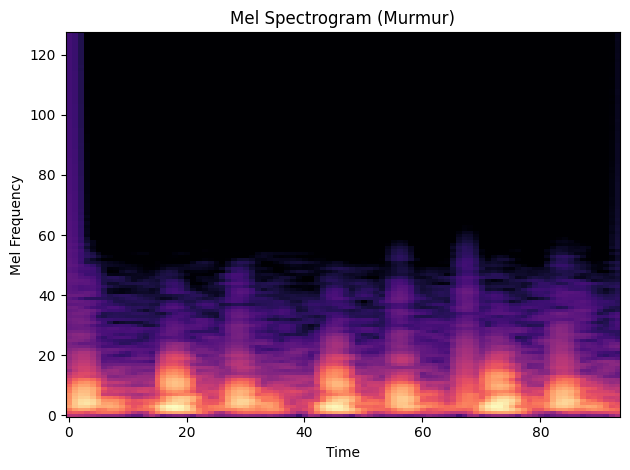

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("final_training_dataset.csv")

sample = df.sample(1).iloc[0]
spec = np.load(sample['spectrogram_path'])

plt.figure()
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.title(f"Mel Spectrogram ({sample['label']})")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🧠 Model Training (CNN)

This stage trains a CNN model on spectrogram features for murmur classification.

---

### ⚙️ Key Steps

- 🔀 **Patient-wise split** (prevents data leakage)  
- ⚖️ **Class weighting** to handle imbalance  
- 📦 **Batch generator** for efficient loading  
- 🧠 CNN with Conv + BatchNorm + Pooling layers  
- 🎯 Output: Binary classification (Normal / Murmur)  

---

### 📊 Training Strategy

- Loss: **Binary Crossentropy**  
- Metrics: **Accuracy, Recall, AUC**  
- Optimizer: **Adam (lr = 1e-4)**  
- Early stopping + best model checkpoint  

---

### 📦 Output

- 💾 Best model saved as:murmur_cnn_keras

In [11]:
# ==========================================
# 4. MODEL TRAINING (FINAL - LEAKAGE SAFE)
# ==========================================

import os
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------
# CONFIG
# ------------------------------------------
CSV_PATH = "final_training_dataset.csv"
BATCH_SIZE = 32
EPOCHS = 50

# ------------------------------------------
# LOAD DATA
# ------------------------------------------
df = pd.read_csv(CSV_PATH)
df['label_encoded'] = df['label'].apply(lambda x: 0 if x == 'Normal' else 1)

# ------------------------------------------
# 🔥 PATIENT-WISE SPLIT (CRITICAL)
# ------------------------------------------
patient_df = df[['patient_id', 'label_encoded']].drop_duplicates()

train_patients, val_patients = train_test_split(
    patient_df,
    test_size=0.2,
    stratify=patient_df['label_encoded'],
    random_state=SEED
)

train_df = df[df['patient_id'].isin(train_patients['patient_id'])]
val_df = df[df['patient_id'].isin(val_patients['patient_id'])]

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

# ------------------------------------------
# CLASS WEIGHTS
# ------------------------------------------
y_train = train_df['label_encoded'].values
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

# ------------------------------------------
# DATA GENERATOR
# ------------------------------------------
class SpectrogramGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for row in batch.itertuples():
            spec = np.load(row.spectrogram_path)

            # Normalize
            spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)

            spec = np.expand_dims(spec, axis=-1)

            X.append(spec)
            y.append(row.label_encoded)

        return np.array(X), np.array(y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Generators
train_gen = SpectrogramGenerator(train_df, BATCH_SIZE, shuffle=True)
val_gen = SpectrogramGenerator(val_df, BATCH_SIZE, shuffle=False)

# Input shape
sample_X, _ = train_gen[0]
input_shape = sample_X[0].shape

print("Input shape:", input_shape)

# ------------------------------------------
# MODEL ARCHITECTURE
# ------------------------------------------
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model

model = build_model(input_shape)
model.summary()

# ------------------------------------------
# TRAINING
# ------------------------------------------
print("\n🚀 Training started...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            "murmur_cnn_best.keras",
            monitor='val_recall',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

print("\n✅ Training complete. Best model saved as 'murmur_cnn_best.keras'")

Train samples: 26996 | Val samples: 6885
Input shape: (128, 94, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 94, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 94, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,883,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,977,409 (11.36 MB)

 Trainable params: 2,976,961 (11.36 MB)

 Non-trainable params: 448 (1.75 KB)


🚀 Training started...
Epoch 1/50


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7911 - auc: 0.8637 - loss: 0.4828 - recall: 0.8174
Epoch 1: val_recall improved from None to 0.94630, saving model to murmur_cnn_best.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 155s 181ms/step - accuracy: 0.8345 - auc: 0.9156 - loss: 0.3676 - recall: 0.8789 - val_accuracy: 0.8520 - val_auc: 0.9569 - val_loss: 0.3198 - val_recall: 0.9463
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8732 - auc: 0.9550 - loss: 0.2570 - recall: 0.9411
Epoch 2: val_recall improved from 0.94630 to 0.95741, saving model to murmur_cnn_best.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 149s 177ms/step - accuracy: 0.8816 - auc: 0.9591 - loss: 0.2453 - recall: 0.9400 - val_accuracy: 0.8739 - val_auc: 0.9681 - val_loss: 0.2735 - val_recall: 0.9574
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8949 - auc: 0.9671 - loss: 0.2147 - recall: 0.9473
Epoch 3: val_recall did not improve from 0.95741
844/844 ━━━━━━━━━━━━━━━━━━━━ 151s 179ms/st

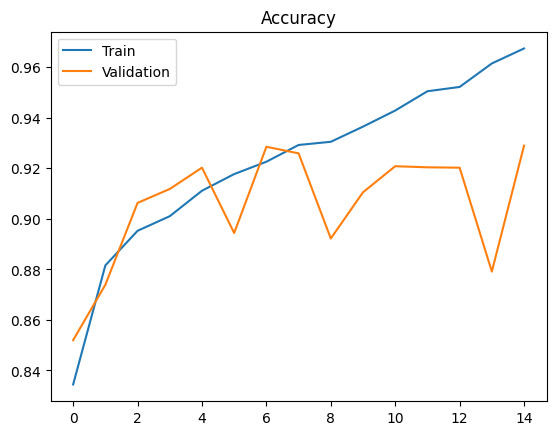

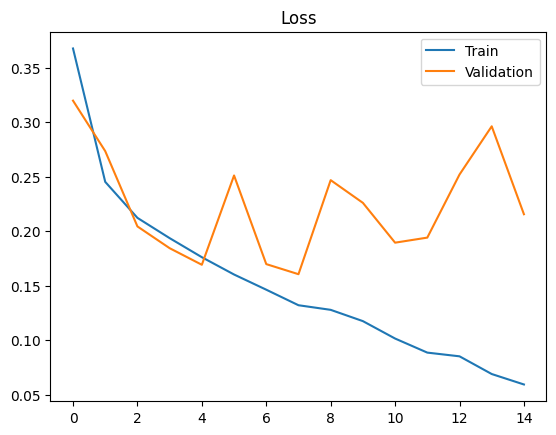

In [12]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

Loading the best model weights...
Gathering true labels from validation set...
Generating predictions (this will take a minute)...
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       0.99      0.86      0.92      5805
  Murmur (1)       0.56      0.96      0.70      1080

    accuracy                           0.87      6885
   macro avg       0.77      0.91      0.81      6885
weighted avg       0.92      0.87      0.89      6885



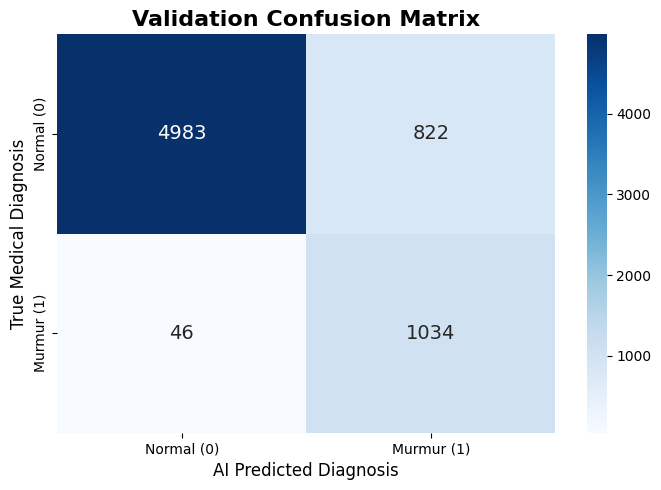

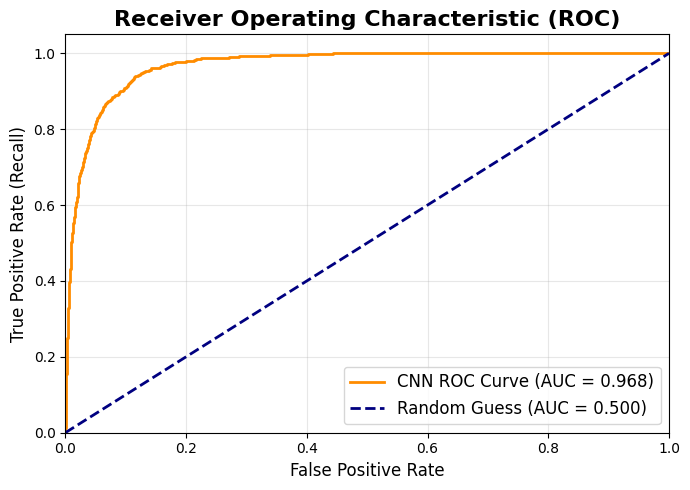

Creating an unshuffled generator for the 80% Training Data...
Gathering true labels from the training set...
Generating predictions for 27,000+ chunks (this will take a few minutes)...
  5/844 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step

d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step

TRAINING SET CLASSIFICATION REPORT (The 80%)
              precision    recall  f1-score   support

  Normal (0)       1.00      0.86      0.92     22811
  Murmur (1)       0.57      0.99      0.72      4185

    accuracy                           0.88     26996
   macro avg       0.78      0.93      0.82     26996
weighted avg       0.93      0.88      0.89     26996



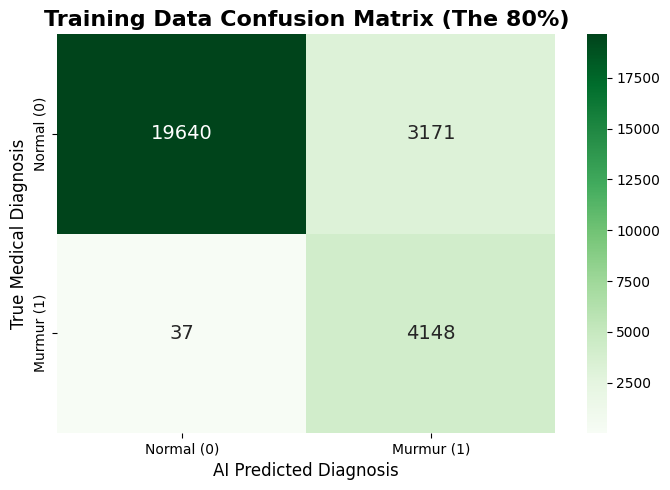

In [13]:
# ==========================================
# 5. Model Evaluation (Clinical Metrics)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

print("Loading the best model weights...")
best_model = tf.keras.models.load_model("murmur_cnn_best.keras")

# 1. Get True Labels from the Validation Generator
print("Gathering true labels from validation set...")
y_true = val_gen.df['label_encoded'].values

# 2. Generate Predictions
print("Generating predictions (this will take a minute)...")
y_pred_probs = best_model.predict(val_gen)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

# --- EVALUATION OUTPUTS ---

# A. Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
target_names = ['Normal (0)', 'Murmur (1)']
print(classification_report(y_true, y_pred_classes, target_names=target_names))

# B. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14})
plt.title('Validation Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Medical Diagnosis', fontsize=12)
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

# C. ROC Curve & AUC Visualization
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CNN ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# ==========================================
# 5b. Evaluate on the 80% Training Data
# ==========================================

print("Creating an unshuffled generator for the 80% Training Data...")
# CRITICAL: shuffle=False so the predictions match the true labels perfectly
train_gen_eval = SpectrogramGenerator(train_df, batch_size=BATCH_SIZE, shuffle=False)

print("Gathering true labels from the training set...")
y_true_train = train_gen_eval.df['label_encoded'].values

print("Generating predictions for 27,000+ chunks (this will take a few minutes)...")
y_pred_probs_train = best_model.predict(train_gen_eval)
y_pred_classes_train = (y_pred_probs_train > 0.5).astype(int).flatten()

# --- EVALUATION OUTPUTS ---

# A. Classification Report
print("\n" + "="*50)
print("TRAINING SET CLASSIFICATION REPORT (The 80%)")
print("="*50)
target_names = ['Normal (0)', 'Murmur (1)']
print(classification_report(y_true_train, y_pred_classes_train, target_names=target_names))

# B. Confusion Matrix Visualization
cm_train = confusion_matrix(y_true_train, y_pred_classes_train)
plt.figure(figsize=(7, 5))
import seaborn as sns
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14})
plt.title('Training Data Confusion Matrix (The 80%)', fontsize=16, fontweight='bold')
plt.ylabel('True Medical Diagnosis', fontsize=12)
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import os

print("Current Working Directory:", os.getcwd())

try:
    df_old = pd.read_csv("preprocessed_dataset.csv")
    print(f"preprocessed_dataset.csv has {len(df_old)} rows.")
except:
    print("preprocessed_dataset.csv not found.")

try:
    df_new = pd.read_csv("final_training_dataset.csv")
    print(f"final_training_dataset.csv has {len(df_new)} rows.")
except:
    print("final_training_dataset.csv not found.")

Current Working Directory: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)
preprocessed_dataset.csv has 4844 rows.
final_training_dataset.csv has 33881 rows.


<div style="font-family: Georgia, serif; font-size: 11pt;">

## ❤️ S1 & S2 Segmentation

Identifies heart sound phases using Shannon Energy.

---

### ⚙️ Key Steps
- Normalize audio  
- Compute & smooth energy  
- Detect peaks → **S1, S2**  
- Classify:
  - Systole (short gap)  
  - Diastole (long gap)  

---

### 🔍 Interpretation
- Peaks = heart sounds  
- Gap length → phase identification  

---

✨ Enables clear temporal analysis of cardiac cycles.

</div>

Loading audio: ./processed_audio/clean_4775_85279_TV.wav


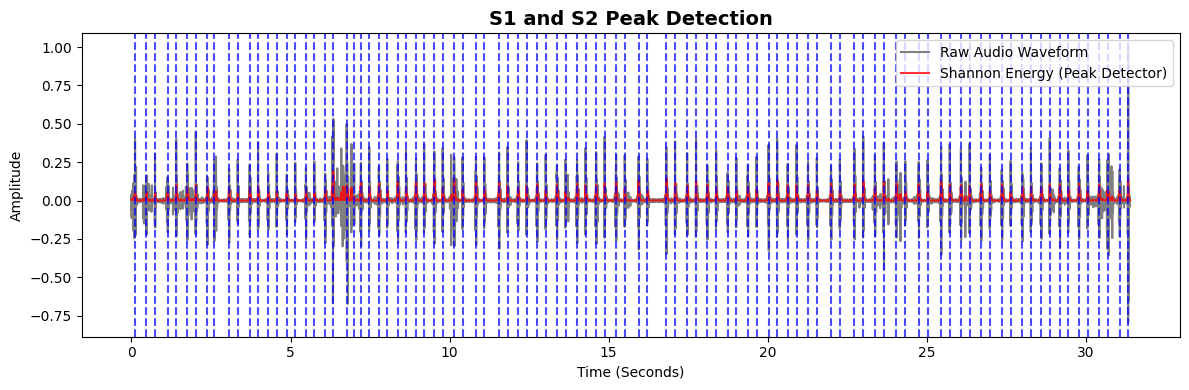


--- Detected Heart Phases ---
Systole (S1->S2): 0.11s to 0.47s
Systole (S1->S2): 0.47s to 0.74s
Systole (S1->S2): 0.74s to 1.14s
Systole (S1->S2): 1.14s to 1.41s
Systole (S1->S2): 1.41s to 1.75s


In [15]:
# ==========================================
# S1, S2, Systole, & Diastole Segmentation
# ==========================================

import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def segment_heart_sounds(y, sr):
    """
    Uses Shannon Energy to extract explicit S1, Systole, S2, and Diastole timing.
    """
    # 1. Normalize the audio
    y_norm = y / np.max(np.abs(y))
    
    # 2. Calculate Shannon Energy (amplifies loud S1/S2 peaks, squashes quiet noise)
    energy = -(y_norm**2) * np.log(y_norm**2 + 1e-10)
    
    # 3. Smooth the energy envelope (20ms window) to make the peaks clear
    window_len = int(sr * 0.02)
    smoothed_energy = np.convolve(energy, np.ones(window_len)/window_len, mode='same')
    
    # 4. Find the actual peaks (S1 and S2)
    distance = int(sr * 0.2) # Minimum distance between heartbeats
    peaks, _ = find_peaks(smoothed_energy, distance=distance, height=np.mean(smoothed_energy))
    
    # 5. Heuristic Classification: Alternate S1 and S2
    # Rule of thumb: The S1->S2 gap (Systole) is usually shorter than the S2->S1 gap (Diastole)
    phases = []
    for i in range(len(peaks) - 1):
        gap = peaks[i+1] - peaks[i]
        if gap < (sr * 0.4): # Less than 400ms gap is likely Systole
            phases.append({'start': peaks[i], 'end': peaks[i+1], 'label': 'Systole (S1->S2)'})
        else:
            phases.append({'start': peaks[i], 'end': peaks[i+1], 'label': 'Diastole (S2->S1)'})
            
    return smoothed_energy, peaks, phases


# --- TEST IT ON ONE OF YOUR AUDIO FILES ---

# Grab the first audio file path from your dataframe
# Make sure your dataframe 'df' from Step 4 is still loaded!
test_audio_path = "./processed_audio/clean_4775_85279_TV.wav"

print(f"Loading audio: {test_audio_path}")
y, sr = librosa.load(test_audio_path, sr=2000)

# Run the segmentation math
energy, peaks, phases = segment_heart_sounds(y, sr)

# Plot the results to prove it works!
time_axis = np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(12, 4))
plt.plot(time_axis, y, color='black', alpha=0.5, label='Raw Audio Waveform')
plt.plot(time_axis, energy, color='red', alpha=0.8, label='Shannon Energy (Peak Detector)')

# Draw vertical lines wherever it found an S1 or S2 peak
for p in peaks:
    plt.axvline(x=p/sr, color='blue', linestyle='--', alpha=0.7)

plt.title("S1 and S2 Peak Detection", fontsize=14, fontweight='bold')
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print out the exact timestamps for the phases
print("\n--- Detected Heart Phases ---")
for phase in phases[:5]: # Just printing the first 5 to keep it clean
    start_sec = phase['start'] / sr
    end_sec = phase['end'] / sr
    print(f"{phase['label']}: {start_sec:.2f}s to {end_sec:.2f}s")

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🔍 Model Prediction & Explainability

This stage combines model prediction with signal-level and visual explanations.

---

### ⚙️ What it shows

- ❤️ **S1/S2 Detection** → highlights heart sound peaks  
- 🎼 **Mel Spectrogram** → time-frequency representation  
- 🔥 **GradCAM** → regions influencing the model decision  
- 🧠 Final prediction with confidence score  

---

### 🔍 Interpretation

- Model predicts **Murmur Detected (high confidence)**  
- Peaks align with cardiac cycles (S1/S2)  
- Spectrogram shows energy concentration in heart sound range  
- GradCAM highlights regions used by the model for prediction  

---

### 🎯 Significance

- ✔ Combines **signal + model + explainability**  
- ✔ Makes predictions **interpretable and trustworthy**  
- ✔ Useful for clinical understanding  

---

✨ Provides an end-to-end interpretable murmur detection system.

</div>


Using sample:
Spectrogram: .\spectrograms\spec_389_4.npy
Audio: ./processed_audio\clean_389_a0390.wav

Processing: clean_389_a0390.wav


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_114']
Received: inputs=Tensor(shape=(1, 128, 94, 1))
  warnings.warn(msg)


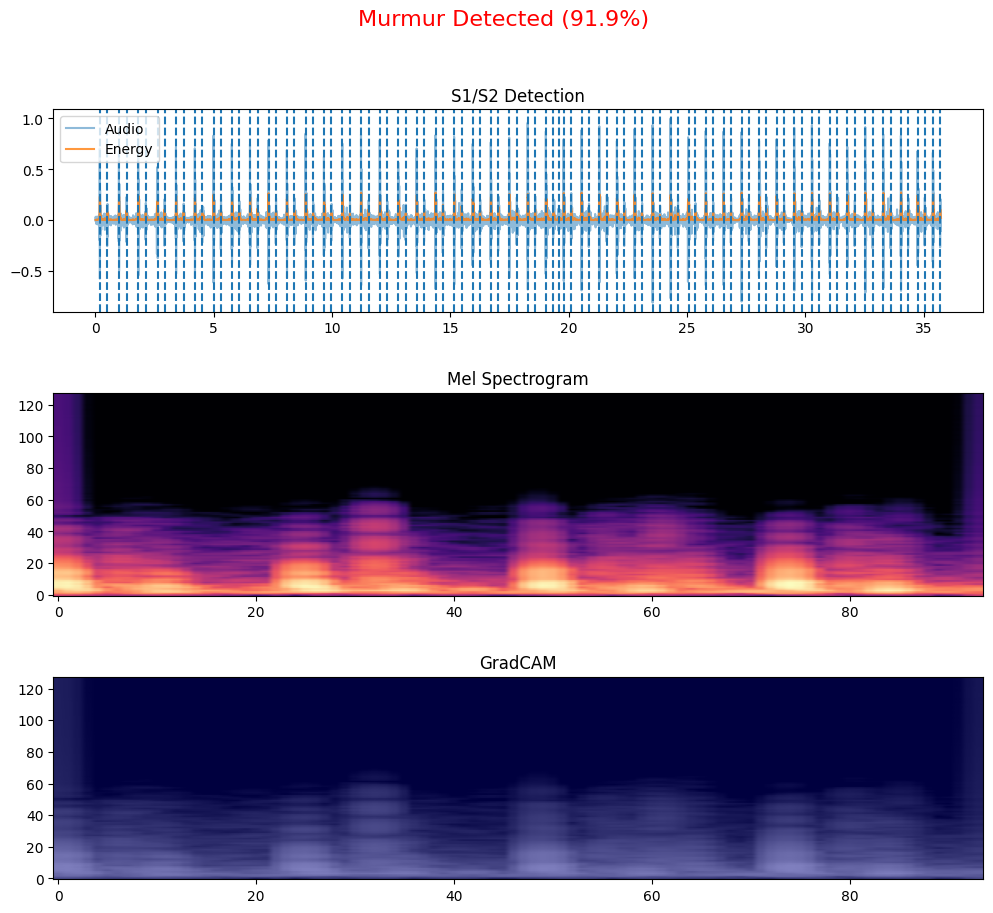

In [16]:
# ==========================================
# 6b. MASTER EXPLAINABILITY PIPELINE (FINAL)
# ==========================================

import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy.signal import find_peaks

# ------------------------------------------
# 1. S1/S2 SEGMENTATION
# ------------------------------------------
def segment_heart_sounds(y, sr):
    y_norm = y / (np.max(np.abs(y)) + 1e-8)

    energy = -(y_norm**2) * np.log(y_norm**2 + 1e-10)

    window_len = int(sr * 0.02)
    smoothed = np.convolve(energy, np.ones(window_len)/window_len, mode='same')

    peaks, _ = find_peaks(
        smoothed,
        distance=int(sr * 0.2),
        height=np.mean(smoothed)
    )

    return y_norm, smoothed, peaks

# ------------------------------------------
# 2. GRADCAM
# ------------------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ------------------------------------------
# 3. VISUALIZATION
# ------------------------------------------
def generate_master_report(audio_path, spec_path, model, threshold=0.25):
    print(f"\nProcessing: {os.path.basename(audio_path)}")

    if not os.path.exists(audio_path):
        print("❌ Audio missing:", audio_path)
        return
    if not os.path.exists(spec_path):
        print("❌ Spectrogram missing:", spec_path)
        return

    y, sr = librosa.load(audio_path, sr=2000)
    spec = np.load(spec_path)

    # Normalize
    spec_norm = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)
    spec_input = np.expand_dims(np.expand_dims(spec_norm, -1), 0)

    # Prediction
    pred = model.predict(spec_input, verbose=0)[0][0]
    label = "Murmur Detected" if pred > threshold else "Normal Heart"
    confidence = pred if pred > threshold else (1 - pred)

    # S1/S2
    y_norm, energy, peaks = segment_heart_sounds(y, sr)

    # GradCAM
    last_conv = [l.name for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
    heatmap = make_gradcam_heatmap(spec_input, model, last_conv)
    heatmap = cv2.resize(heatmap, (spec.shape[1], spec.shape[0]))

    # Plot
    fig, ax = plt.subplots(3, 1, figsize=(12, 10))
    plt.subplots_adjust(hspace=0.4)

    color = "red" if label == "Murmur Detected" else "green"
    fig.suptitle(f"{label} ({confidence:.1%})", color=color, fontsize=16)

    # Waveform
    t = np.linspace(0, len(y)/sr, len(y))
    ax[0].plot(t, y_norm, alpha=0.5, label="Audio")
    ax[0].plot(t, energy, alpha=0.8, label="Energy")
    for p in peaks:
        ax[0].axvline(p/sr, linestyle='--')
    ax[0].legend()
    ax[0].set_title("S1/S2 Detection")

    # Spectrogram
    ax[1].imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax[1].set_title("Mel Spectrogram")

    # GradCAM
    ax[2].imshow(spec, aspect='auto', origin='lower', cmap='gray')
    ax[2].imshow(heatmap, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
    ax[2].set_title("GradCAM")

    plt.show()

# ------------------------------------------
# 4. MODEL
# ------------------------------------------
def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

# ------------------------------------------
# 5. 🔥 AUTO MAP SPECTROGRAM → AUDIO (FINAL FIX)
# ------------------------------------------
df = pd.read_csv("final_training_dataset.csv")

sample = df.sample(1).iloc[0]
test_npy = sample['spectrogram_path']

# Extract index from spectrogram filename
file_name = os.path.basename(test_npy)   # spec_389_4.npy
index_id = file_name.split('_')[1]       # 389

# Find matching audio
audio_candidates = glob.glob(f"./processed_audio/clean_{index_id}_*.wav")

if len(audio_candidates) == 0:
    raise FileNotFoundError(f"No audio found for index {index_id}")

test_wav = audio_candidates[0]

print("\nUsing sample:")
print("Spectrogram:", test_npy)
print("Audio:", test_wav)

# ------------------------------------------
# 6. LOAD MODEL
# ------------------------------------------
spec_shape = np.load(test_npy).shape
input_shape = (spec_shape[0], spec_shape[1], 1)

model = build_model(input_shape)
model.load_weights("murmur_cnn_best.keras")

# ------------------------------------------
# 7. RUN REPORT
# ------------------------------------------
generate_master_report(test_wav, test_npy, model)

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🔬 SHAP Explainability

This step explains model predictions by highlighting important regions in the spectrogram.

---

### ⚙️ What it does

- 📥 Loads trained model and a sample spectrogram  
- 📊 Applies SHAP (DeepExplainer)  
- 🔥 Computes feature importance for each pixel  
- 🖼️ Visualizes important regions  

---

### 🔍 Interpretation

- Left: Original Mel spectrogram  
- Right: SHAP importance map  
- Brighter regions → higher influence on prediction  

---

### 🎯 Significance

- ✔ Identifies **what features the model relies on**  
- ✔ Improves transparency of predictions  
- ✔ Complements GradCAM for deeper insight  

---

✨ Provides pixel-level explanation of murmur detection.

</div>

Loading model...
Using spectrogram: .\spectrograms\spec_1340_6.npy
Initializing SHAP...
Computing SHAP values...


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1, 128, 94, 1))']
  warnings.warn(msg)
d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2)\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(2, 128, 94, 1))']
  warnings.warn(msg)


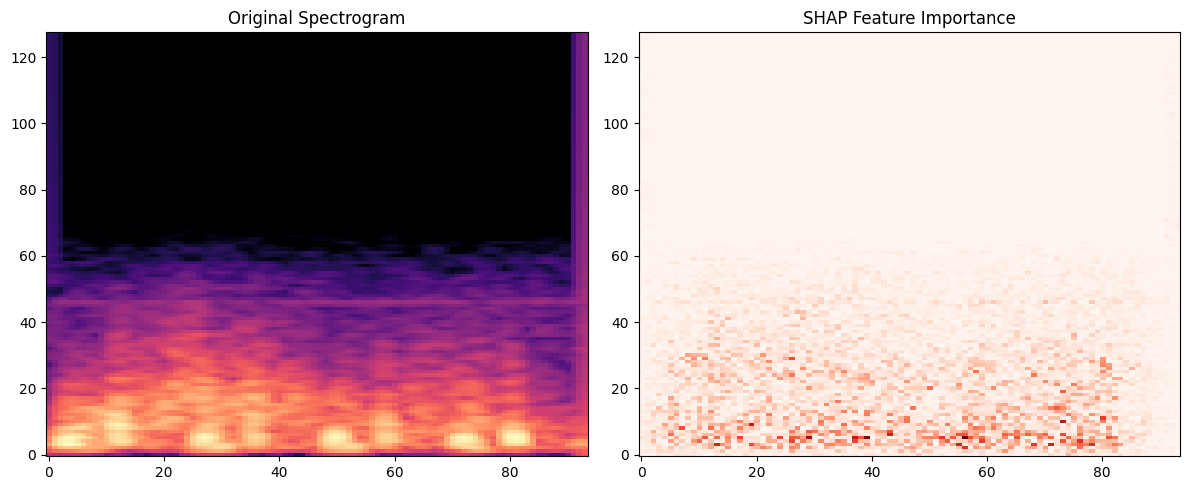

In [17]:
# ==========================================
# 6c. SHAP EXPLAINABILITY (FINAL FIXED)
# ==========================================

import shap
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. LOAD MODEL
# ------------------------------------------
print("Loading model...")
best_model = tf.keras.models.load_model("murmur_cnn_best.keras")

# ------------------------------------------
# 2. LOAD VALID SAMPLE (NO HARDCODING)
# ------------------------------------------
df = pd.read_csv("final_training_dataset.csv")

sample = df.sample(1).iloc[0]
test_npy = sample['spectrogram_path']

print("Using spectrogram:", test_npy)

spec = np.load(test_npy)

# ------------------------------------------
# 3. PREPROCESS (MATCH TRAINING)
# ------------------------------------------
spec_norm = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)
spec_input = np.expand_dims(np.expand_dims(spec_norm, axis=-1), axis=0)

# ------------------------------------------
# 4. SHAP EXPLAINER
# ------------------------------------------
print("Initializing SHAP...")

background = np.zeros((1, spec.shape[0], spec.shape[1], 1))

explainer = shap.DeepExplainer(best_model, background)

# ------------------------------------------
# 5. COMPUTE SHAP
# ------------------------------------------
print("Computing SHAP values...")

shap_values = explainer.shap_values(spec_input)

# Handle list output
if isinstance(shap_values, list):
    shap_numpy = shap_values[0]
else:
    shap_numpy = shap_values

# ------------------------------------------
# 6. VISUALIZATION
# ------------------------------------------
plt.figure(figsize=(12, 5))

# Original spectrogram
plt.subplot(1, 2, 1)
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.title("Original Spectrogram")

# SHAP importance
plt.subplot(1, 2, 2)
plt.imshow(np.abs(shap_numpy[0, :, :, 0]),
           aspect='auto',
           origin='lower',
           cmap='Reds')
plt.title("SHAP Feature Importance")

plt.tight_layout()
plt.show()